### Imports

In [14]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
import seaborn as sb

from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.pipeline import Pipeline

from sklearn.preprocessing import LabelEncoder, StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.decomposition import PCA

from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

from sklearn.metrics import classification_report, f1_score

### Read Data

In [6]:
df = pd.read_csv("predictive_maintenance.csv")

In [7]:
# Encode target strings to 0, 1
le = LabelEncoder()
df['Failure Type Encoded'] = le.fit_transform(df['Failure Type'])

# Split features and targets
x = df.drop(['Target', 'Failure Type', 'Failure Type Encoded'], axis=1)
y = df[['Failure Type Encoded']]

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2)
y_train = y_train.values.ravel()

### Pipelines

In [16]:
categorical_features = ['Type']
numeric_features = ['Air temperature [K]', 'Process temperature [K]',
                    'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]']

# Create column transformer
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features), # Normalize sensor readings
        ('cat', OneHotEncoder(drop='first'), categorical_features) # Encode product type
    ]
)

# Create pipelines for classifiers
rf_pipe = Pipeline([
    ('pre', preprocessor),
    ('pca', PCA()), # Optional dimensionality reduction
    ('clf', RandomForestClassifier())
])

xgb_pipe = Pipeline([
    ('pre', preprocessor),
    ('pca', PCA()), # Optional dimensionality reduction
    ('clf', XGBClassifier())
])

### Search CV

#### Random Forest Classifier

In [17]:
# Set parameter grids for search cross-validation
rf_param_grid = {
    'clf__n_estimators': [100, 200, 300, 400, 500],
    'clf__max_depth': [None, 10, 20, 30, 40, 50],
    'clf__min_samples_split': [2, 5, 10, 15],
    'clf__min_samples_leaf': [1, 2, 4, 6],
    'clf__max_features': ['sqrt', 'log2', None, 0.5],
    'clf__bootstrap': [True, False],
    'clf__class_weight': ['balanced', 'balanced_subsample']
}

# Using RandomizedSearchCV to search random param combinations
rf_search = RandomizedSearchCV(
    rf_pipe, 
    param_distributions=rf_param_grid,
    n_iter=200,  # Try 50 random combinations
    scoring='f1_macro', # F1 macro focuses on class imbalance
    cv=3,
    n_jobs=-1,
    verbose=1,
    random_state=42
)
rf_search.fit(x_train, y_train)

Fitting 3 folds for each of 200 candidates, totalling 600 fits


RandomizedSearchCV(cv=3,
                   estimator=Pipeline(steps=[('pre',
                                              ColumnTransformer(transformers=[('num',
                                                                               StandardScaler(),
                                                                               ['Air '
                                                                                'temperature '
                                                                                '[K]',
                                                                                'Process '
                                                                                'temperature '
                                                                                '[K]',
                                                                                'Rotational '
                                                                                'speed '
                                                                                '[rpm]',
                                                                                'Torque '
                                                                                '[Nm]',
                                                                                'Tool '
                                                                                'wear '
                                                                                '[min]']),
                                                                              ('cat',
                                                                               OneHotEncoder(drop='first'),
                                                                               ['Type'])])),
                                             ('pca', PCA()),
                                             ('clf',
                                              RandomForestClassifier())]),
                   n_iter=200, n_jobs=-1,
                   param_distributions={'clf__bootstrap': [True, False],
                                        'clf__class_weight': ['balanced',
                                                              'balanced_subsample'],
                                        'clf__max_depth': [None, 10, 20, 30, 40,
                                                           50],
                                        'clf__max_features': ['sqrt', 'log2',
                                                              None, 0.5],
                                        'clf__min_samples_leaf': [1, 2, 4, 6],
                                        'clf__min_samples_split': [2, 5, 10,
                                                                   15],
                                        'clf__n_estimators': [100, 200, 300,
                                                              400, 500]},
                   random_state=42, scoring='f1_macro', verbose=1)

In [18]:
# Use best Random Forest model from CV
best_rf = rf_search.best_estimator_
y_pred = best_rf.predict(x_test)

with open("rf_results.txt", "a") as f:
    f.write("\n\n" + classification_report(y_test, y_pred))

c:\Users\caide\uv_projects\turbofan\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\caide\uv_projects\turbofan\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\caide\uv_projects\turbofan\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", le

#### XGBoost

In [22]:
xgb_param_grid = [
    # If using PCA
    {
        'pca__n_components': [None, 0.95, 0.9, 0.85],
        'clf__n_estimators': [100, 200, 300, 400, 500],
        'clf__learning_rate': [0.01, 0.05, 0.1, 0.2, 0.3],
        'clf__max_depth': [1, 2, 3, 5, 7, 9],
        'clf__subsample': [0.6, 0.8, 1.0],
        'clf__colsample_bytree': [0.5, 0.6, 0.8, 1.0],
        'clf__gamma': [0, 1, 3, 5],
        'clf__reg_lambda': [0, 1, 5, 10, 20],
        'clf__reg_alpha': [0, 1, 5, 10, 20],
        'clf__scale_pos_weight': [1, 2, 5, 10],  # helpful for imbalanced classes
    },
    #  If not using PCA
    {
        'pca': ['passthrough'],
        'clf__n_estimators': [100, 200, 300, 400, 500],
        'clf__learning_rate': [0.01, 0.05, 0.1, 0.2, 0.3],
        'clf__max_depth': [1, 2, 3, 5, 7, 9],
        'clf__subsample': [0.6, 0.8, 1.0],
        'clf__colsample_bytree': [0.5, 0.6, 0.8, 1.0],
        'clf__gamma': [0, 1, 3, 5],
        'clf__reg_lambda': [0, 1, 5, 10, 20],
        'clf__reg_alpha': [0, 1, 5, 10, 20],
        'clf__scale_pos_weight': [1, 2, 5, 10],  # helpful for imbalanced classes
    }
]

xgb_search = RandomizedSearchCV(
    xgb_pipe, 
    param_distributions=xgb_param_grid,
    n_iter=300,  # Try 50 random combinations
    scoring='f1_macro', # F1 macro focuses on class imbalance
    cv=3,
    n_jobs=-1,
    verbose=1,
    random_state=42
)
xgb_search.fit(x_train, y_train)

Fitting 3 folds for each of 300 candidates, totalling 900 fits


c:\Users\caide\uv_projects\turbofan\.venv\Lib\site-packages\xgboost\training.py:183: UserWarning: [00:03:36] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "scale_pos_weight" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


RandomizedSearchCV(cv=3,
                   estimator=Pipeline(steps=[('pre',
                                              ColumnTransformer(transformers=[('num',
                                                                               StandardScaler(),
                                                                               ['Air '
                                                                                'temperature '
                                                                                '[K]',
                                                                                'Process '
                                                                                'temperature '
                                                                                '[K]',
                                                                                'Rotational '
                                                                                'speed '
                                                                                '[rpm]',
                                                                                'Torque '
                                                                                '[Nm]',
                                                                                'Tool '
                                                                                'wear '
                                                                                '[min]']),
                                                                              ('cat',
                                                                               OneHotEncoder(drop='first'),
                                                                               ['Type'])])),
                                             ('pca', PCA()),
                                             ('clf',
                                              XGBClassifier(base_score=None,
                                                            booster=None,
                                                            callback...
                                        {'clf__colsample_bytree': [0.5, 0.6,
                                                                   0.8, 1.0],
                                         'clf__gamma': [0, 1, 3, 5],
                                         'clf__learning_rate': [0.01, 0.05, 0.1,
                                                                0.2, 0.3],
                                         'clf__max_depth': [1, 2, 3, 5, 7, 9],
                                         'clf__n_estimators': [100, 200, 300,
                                                               400, 500],
                                         'clf__reg_alpha': [0, 1, 5, 10, 20],
                                         'clf__reg_lambda': [0, 1, 5, 10, 20],
                                         'clf__scale_pos_weight': [1, 2, 5, 10],
                                         'clf__subsample': [0.6, 0.8, 1.0],
                                         'pca': ['passthrough']}],
                   random_state=42, scoring='f1_macro', verbose=1)

In [23]:
# Use best XGBoost model from CV
best_xgb = xgb_search.best_estimator_
y_pred = best_xgb.predict(x_test)

print("Best Params")
print(best_xgb.named_steps['clf'].get_params())

with open("xgb_results.txt", "a") as f:
    f.write("\n\n" + classification_report(y_test, y_pred))

Best Params
{'objective': 'multi:softprob', 'base_score': None, 'booster': None, 'callbacks': None, 'colsample_bylevel': None, 'colsample_bynode': None, 'colsample_bytree': 1.0, 'device': None, 'early_stopping_rounds': None, 'enable_categorical': False, 'eval_metric': None, 'feature_types': None, 'feature_weights': None, 'gamma': 0, 'grow_policy': None, 'importance_type': None, 'interaction_constraints': None, 'learning_rate': 0.3, 'max_bin': None, 'max_cat_threshold': None, 'max_cat_to_onehot': None, 'max_delta_step': None, 'max_depth': 5, 'max_leaves': None, 'min_child_weight': None, 'missing': nan, 'monotone_constraints': None, 'multi_strategy': None, 'n_estimators': 100, 'n_jobs': None, 'num_parallel_tree': None, 'random_state': None, 'reg_alpha': 1, 'reg_lambda': 10, 'sampling_method': None, 'scale_pos_weight': 10, 'subsample': 0.6, 'tree_method': None, 'validate_parameters': None, 'verbosity': None}


c:\Users\caide\uv_projects\turbofan\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\caide\uv_projects\turbofan\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\caide\uv_projects\turbofan\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", le

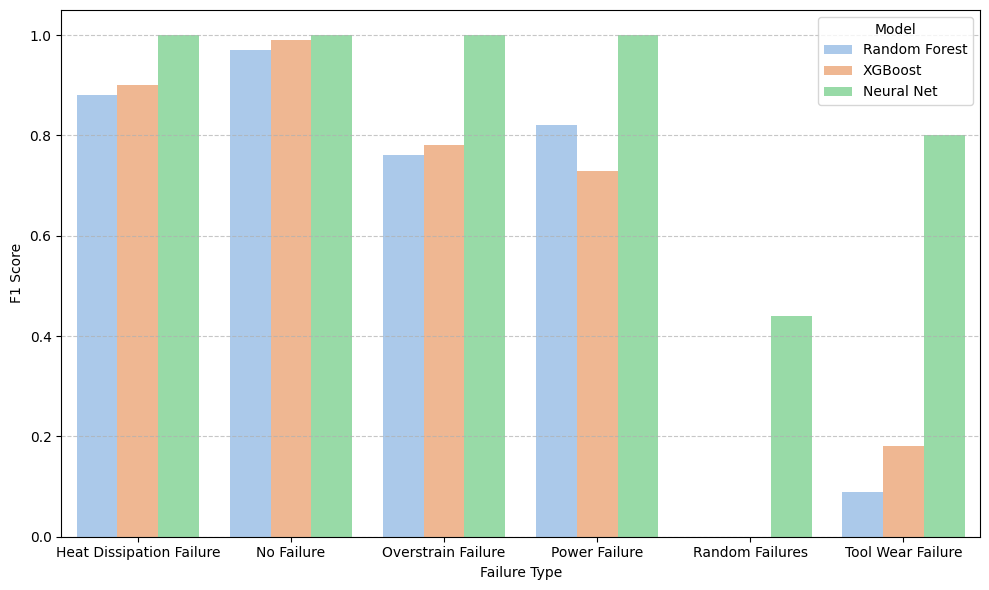

In [ ]:
f1_rf = [0.88, 0.97, 0.76, 0.82, 0.00, 0.09]
f1_xgb = [0.90, 0.99, 0.78, 0.73, 0.00, 0.18]
f1_nn = [1.00, 1.00, 1.00, 1.00, 0.44, 0.80]

classes = ['Heat Dissipation Failure', 'No Failure', 'Overstrain Failure',
           'Power Failure', 'Random Failures', 'Tool Wear Failure']

df = pd.DataFrame({
    'Class': classes * 3,
    'F1 Score': f1_rf + f1_xgb + f1_nn,
    'Model': ['Random Forest'] * len(classes) +
             ['XGBoost'] * len(classes) +
             ['Neural Net'] * len(classes)
})


plt.figure(figsize=(10, 6))
sb.barplot(data=df, x='Class', y='F1 Score', hue='Model', palette='pastel')
plt.ylim(0, 1.05)
plt.ylabel('F1 Score')
plt.xlabel('Failure Type')
plt.legend(title='Model')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [ ]:
best_xgb = xgb_search.best_estimator_
y_pred = best_xgb.predict(x_test)

# For each target
for i, target in enumerate(y.columns):
    with open("xgb_results.txt", "w") as f:
        f.write("\n\n" + classification_report(y_test, y_pred))

c:\Users\caide\uv_projects\turbofan\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\caide\uv_projects\turbofan\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\caide\uv_projects\turbofan\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", le

In [ ]:
best_gbc = gbc_search.best_estimator_
y_pred = best_gbc.predict(x_test)

# For each target
for i, target in enumerate(y.columns):
    with open("gbc_results.txt", "w") as f:
        f.write("\n\n" + classification_report(y_test, y_pred))

In [ ]:
y_pred = gbt.predict(x_test)

# For each target
for i, target in enumerate(y.columns):
    print(f"Classification Report for {target}:\n")
    print(classification_report(y_test, y_pred))

Classification Report for Failure Type Encoded:

              precision    recall  f1-score   support

           0       0.93      0.96      0.95        27
           1       0.99      1.00      0.99      1921
           2       0.89      0.53      0.67        15
           3       1.00      0.96      0.98        23
           4       0.00      0.00      0.00         2
           5       0.00      0.00      0.00        12

    accuracy                           0.98      2000
   macro avg       0.63      0.57      0.60      2000
weighted avg       0.98      0.98      0.98      2000

